# Visualizer 2.0: Focusing on the Key Generations

You're right. The first 6-7 generations in both trees are a single line, which isn't very helpful and makes the tree large and hard to read.

The solution is to "zoom in" on the part of the tree that matters. We can do this by finding a more recent common ancestor and starting our visualization from them.

-   For the **Heike**, the tree branches significantly at **Tadamori** (Kiyomori's father).
-   For the **Genji**, the tree branches at **Yoshiie** (who has two sons) and then explodes at his grandson **Tameyoshi**. We'll start at `Yoshiie` to see the full context.

We'll add a helper function `find_node_by_name` to search the JSON and then use our original `build_tree` function on the resulting sub-tree.

In [1]:
# First, make sure you have the library installed.
# Run this cell if you don't have graphviz.
!pip install graphviz

In [2]:
import graphviz
import json

# This is the JSON data you provided
data = {
  "genealogies": [
    {
      "clan": "Heike",
      "tree": {
        "name": "Kwammu Tenno",
        "children": [
          {
            "name": "Katsurabara Shinno",
            "children": [
              {
                "name": "Takami-no-O",
                "children": [
                  {
                    "name": "Takamochi",
                    "children": [
                      {
                        "name": "Kunika",
                        "children": [
                          {
                            "name": "Sadamori",
                            "children": [
                              {
                                "name": "Korehira",
                                "children": [
                                  {
                                    "name": "Masanori",
                                    "children": [
                                      {
                                        "name": "Masahira",
                                        "children": [
                                          {
                                            "name": "Masamori",
                                            "children": [
                                              {
                                                "name": "Tadamori",
                                                "children": [
                                                  {
                                                    "name": "Kiyomori",
                                                    "children": [
                                                      {
                                                        "name": "Shigemori",
                                                        "children": [
                                                          { "name": "Koremori" },
                                                          { "name": "Sukemori" },
                                                          { "name": "Kiyotsune" },
                                                          { "name": "Arimori" },
                                                          { "name": "Tadafusa" },
                                                          { "name": "Moromori" },
                                                          { "name": "Munezane" },
                                                          { "name": "Shigezane" },
                                                          { "name": "Yukizane" },
                                                          { "name": "Motomori" }
                                                        ]
                                                      },
                                                      {
                                                        "name": "Munemori",
                                                        "children": [
                                                          { "name": "Kiyomune" },
                                                          { "name": "Yoshimune" }
                                                        ]
                                                      },
                                                      {
                                                        "name": "Tomomori",
                                                        "children": [
                                                          { "name": "Tomoakira" },
                                                          { "name": "Tomotada" },
                                                          { "name": "Tomomune" },
                                                          { "name": "Shigenao" }
                                                        ]
                                                      },
                                                      { "name": "Shigehira" },
                                                      { "name": "Tomonori" },
                                                      { "name": "Kiyofusa" },
                                                      { "name": "Koretoshi" },
                                                      { "name": "Kiyosada" },
                                                      { "name": "Kiyokuni" },
                                                      { "name": "Yoshihira" },
                                                      { "name": "Toku-ko (Kenreimon-in)" }
                                                    ]
                                                  },
                                                  { "name": "Tadamasa" },
                                                  {
                                                    "name": "Tsunemori",
                                                    "children": [
                                                      { "name": "Tsunemasa" },
                                                      { "name": "Tsunetoshi" },
                                                      { "name": "Atsumori" }
                                                    ]
                                                  },
                                                  {
                                                    "name": "Norimori",
                                                    "children": [
                                                      { "name": "Michimori" },
                                                      { "name": "Noritsune" },
                                                      { "name": "Narimori" },
                                                      { "name": "Naomori" }
                                                    ]
                                                  },
                                                  {
                                                    "name": "Yorimori",
                                                    "children": [
                                                      { "name": "Tamemori" },
                                                      { "name": "Mitsumori" }
                                                    ]
                                                  },
                                                  { "name": "Tadanori" }
                                                ]
                                              }
                                            ]
                                          }
                                        ]
                                      }
                                    ]
                                  }
                                ]
                              }
                            ]
                          }
                        ]
                      }
                    ]
                  }
                ]
              }
            ]
          }
        ]
      }
    },
    {
      "clan": "Seiwa Genji",
      "tree": {
        "name": "Seiwa Tenno",
        "children": [
          {
            "name": "Sadazumi",
            "children": [
              {
                "name": "Tsunemoto",
                "children": [
                  {
                    "name": "Mitsunaka",
                    "children": [
                      { "name": "Tameyori" },
                      {
                        "name": "Yorinobu",
                        "children": [
                          {
                            "name": "Yoriyoshi",
                            "children": [
                              {
                                "name": "Yoshiie",
                                "children": [
                                  {
                                    "name": "Yoshichika",
                                    "children": [
                                      { "name": "Yoshihiro" }
                                    ]
                                  },
                                  {
                                    "name": "Tameyoshi",
                                    "children": [
                                      {
                                        "name": "Yoshitomo",
                                        "children": [
                                          { "name": "Yoshihira" },
                                          { "name": "Tomonaga" },
                                          {
                                            "name": "Yoritomo",
                                            "children": [
                                              {
                                                "name": "Yoriie",
                                                "children": [
                                                  { "name": "Ichiman Maru" },
                                                  { "name": "Kugyo" },
                                                  { "name": "Senju Maru" },
                                                  { "name": "Yoshikado" }
                                                ]
                                              },
                                              { "name": "Sanetomo" }
                                            ]
                                          },
                                          { "name": "Mareyoshi" },
                                          { "name": "Noriyori Hanen" },
                                          { "name": "Zenjo" },
                                          { "name": "Gien" },
                                          { "name": "Yoshitsune" }
                                        ]
                                      },
                                      {
                                        "name": "Yoshikata",
                                        "children": [
                                          { "name": "Nakaie" },
                                          { "name": "Nakamitsu" },
                                          { "name": "Nakata" },
                                          {
                                            "name": "Yoshinaka",
                                            "children": [
                                              { "name": "Yoshitaka" }
                                            ]
                                          }
                                        ]
                                      },
                                      { "name": "Yorikata" },
                                      { "name": "Yorinaka" },
                                      { "name": "Tamemune" },
                                      { "name": "Tametomo" },
                                      { "name": "Tamenaka" },
                                      { "name": "Yukiie" }
                                    ]
                                  }
                                ]
                              }
                            ]
                          }
                        ]
                      }
                    ]
                  }
                ]
              }
            ]
          }
        ]
      }
    }
  ]
}

### Helper Functions

We'll use two functions:
1.  `find_node_by_name`: This searches the tree for a node with a specific name and returns it.
2.  `build_tree`: This is our original recursive function to build the `graphviz` tree.

In [3]:
def find_node_by_name(node, name):
    """
    Recursively searches a node and its children for
    a node with the given name.
    """
    if node['name'] == name:
        return node
    
    if 'children' in node:
        for child in node['children']:
            found = find_node_by_name(child, name)
            if found:
                return found
    return None

def build_tree(graph, node):
    """
    Recursively adds nodes and edges to a Graphviz graph
    from a nested dictionary.
    """
    node_name = node['name']
    graph.node(node_name)
    
    if 'children' in node and node['children']:
        for child in node['children']:
            child_name = child['name']
            graph.node(child_name)
            graph.edge(node_name, child_name)
            build_tree(graph, child)

### 1. Visualize Heike (Starting from Tadamori)

This is much cleaner. We see Tadamori at the root, his children (including Kiyomori) as the next level, and their children branching off.

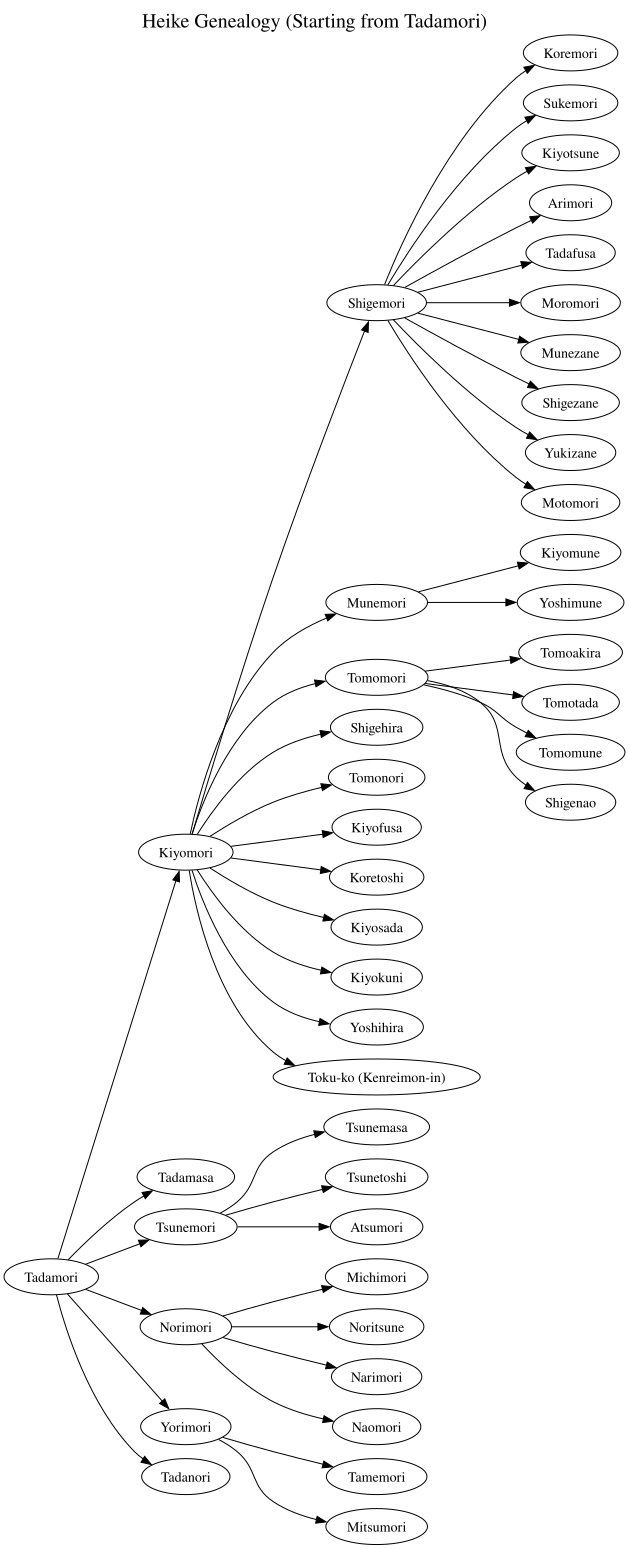

In [4]:
# Get the full Heike tree
heike_root = data['genealogies'][0]['tree']

# Find the new starting point: 'Tadamori'
new_heike_root = find_node_by_name(heike_root, 'Tadamori')

# Create the graph
heike_zoom_graph = graphviz.Digraph(name='Heike')
heike_zoom_graph.attr(
    rankdir='LR',  # Left-to-Right layout
    label='Heike Genealogy (Starting from Tadamori)',
    labelloc='t',
    fontsize='20',
    nodesep='0.2',
    ranksep='0.5' # A bit more space between generations
)

# Build the graph from our new root
if new_heike_root:
    build_tree(heike_zoom_graph, new_heike_root)
else:
    print("Error: 'Tadamori' not found.")

heike_zoom_graph

### 2. Visualize Genji (Starting from Yoshiie)

Similarly, we'll start the Genji tree from **Yoshiie**. This clearly shows the two main branches (Yoshichika and Tameyoshi) and the subsequent explosion of key figures like Yoshitomo, Yoshinaka, and Yoritomo.

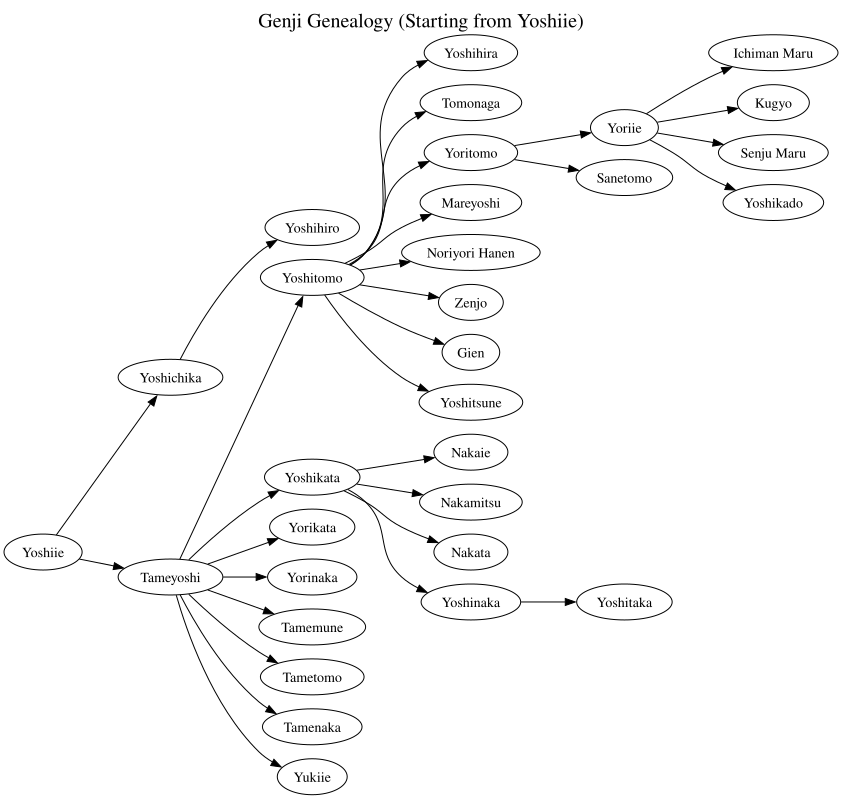

In [5]:
# Get the full Genji tree
genji_root = data['genealogies'][1]['tree']

# Find the new starting point: 'Yoshiie'
new_genji_root = find_node_by_name(genji_root, 'Yoshiie')

# Create the graph
genji_zoom_graph = graphviz.Digraph(name='Genji')
genji_zoom_graph.attr(
    rankdir='LR',
    label='Genji Genealogy (Starting from Yoshiie)',
    labelloc='t',
    fontsize='20',
    nodesep='0.2',
    ranksep='0.5'
)

# Build the graph from our new root
if new_genji_root:
    build_tree(genji_zoom_graph, new_genji_root)
else:
    print("Error: 'Yoshiie' not found.")

genji_zoom_graph